In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

In [2]:
def plot_simple_fill(df, color, label):
    # Filter for target r-value and drop the NaNs used for segment breaks
    df_filtered = df[np.isclose(df['r_value'], r_target)].dropna()
    
    if df_filtered.empty:
        return
        
    # --- THE SIMPLE METHOD ---
    # Round the mass to the nearest integer so we can group points together safely
    df_filtered['mZp_round'] = df_filtered['mZp_GeV'].round(0)
    
    # For every mass point, find the absolute minimum cross-section.
    # This automatically flattens any loops or overhangs into a single clean line.
    line_data = df_filtered.groupby('mZp_round')['xsecXBR_pb'].min().reset_index()
    
    # Sort strictly from left to right
    line_data = line_data.sort_values('mZp_round')
    
    x = line_data['mZp_round'].values
    y = line_data['xsecXBR_pb'].values
    
    # Extend to the y-axis if the data starts after 1500
    if len(x) > 0 and x[0] > 1500.0:
        x = np.insert(x, 0, 1500.0)
        y = np.insert(y, 0, y[0])
        
    # Plot the line linking the points
    plt.plot(x, y, color=color, linewidth=2, linestyle='solid', label=label)
    
    # Fill the region between the dots and the maximum value
    plt.fill_between(x, y, upper_limit, color=color, alpha=0.3)

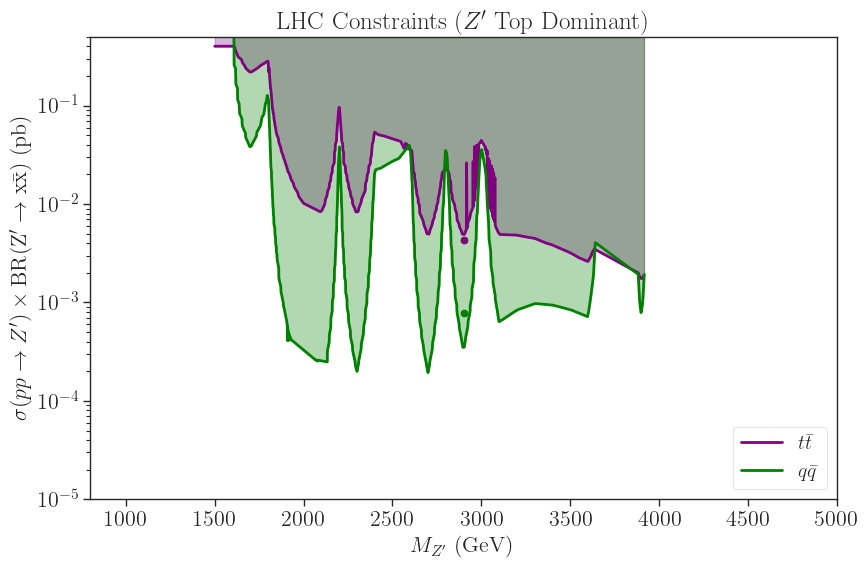

In [3]:
# 1. Load Data
df_qq = pd.read_csv('./Exclusion_Contours_topDom_qq.csv')
df_tt = pd.read_csv('./Exclusion_Contours_topDom_tt.csv')

r_target = 1.0 / 1.5
upper_limit = 0.5  

# ---------------------------------------------------------
# Create the Final Plot
# ---------------------------------------------------------
fig = plt.figure(figsize=(9, 6))

plot_simple_fill(df_tt, color='purple', label=r'$t\bar{t}$')
plot_simple_fill(df_qq, color='green', label=r'$q\bar{q}$')

# Formatting
plt.legend(loc='lower right', fontsize=14.5, framealpha=0.5)
plt.yscale('log')
plt.xlabel(r'$M_{Z^\prime}$ (GeV)', fontsize=16)
plt.ylabel(r'$\sigma(pp \to Z^\prime) \times \rm{BR}(Z^\prime \to x\bar{x})$ (pb)', fontsize=16)

plt.xlim(800, 5000)
plt.ylim(1e-5, upper_limit)
plt.scatter([2900],[0.03480692605701812/9.569138e-01 * 2.154309e-02], color = 'green', label = 'Current point')
plt.scatter([2900],[0.03480692605701812/8], color = 'purple', label = 'Current point')

plt.title(r'LHC Constraints ($Z^\prime$ Top Dominant)', fontsize=18)
plt.tight_layout()
plt.savefig('allExclusions_v2_Corrected.png', dpi=300)
plt.show()


--- UNIFIED SAFE PHYSICS MODEL (M = 3800 GeV) ---
Limiting Channel : q qbar
Unified g_q      : 1.271799e-01
Unified g_t      : 3.054738e-01 (Top Dominant)
Resulting S_tt   : 1.89e-03 pb (Safe Limit was 1.90e-03)
Resulting S_qq   : 6.54e-04 pb (Safe Limit was 6.54e-04)


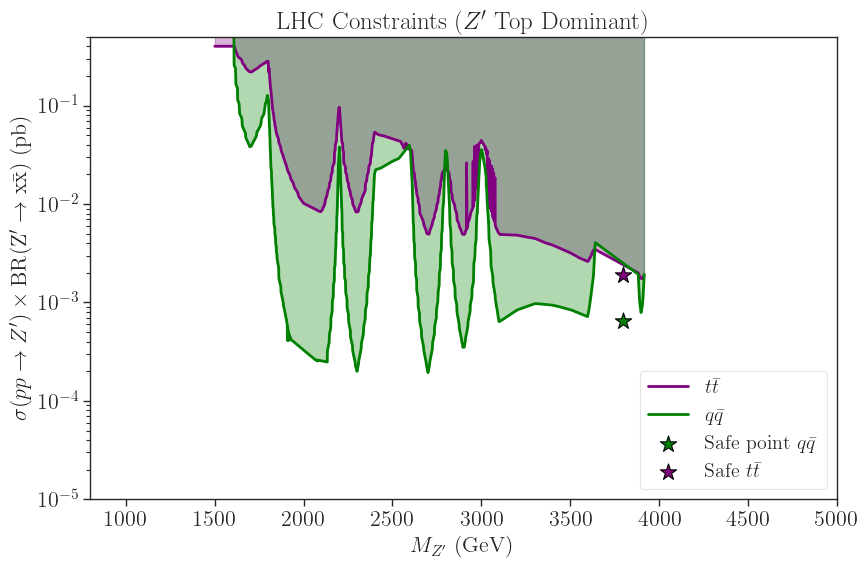

In [5]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =========================================================
# 1. Helper Functions
# =========================================================

def plot_simple_fill(df, r_target, color, label, upper_limit):
    df_filtered = df[np.isclose(df['r_value'], r_target)].dropna()
    if df_filtered.empty: return
        
    df_filtered['mZp_round'] = df_filtered['mZp_GeV'].round(0)
    line_data = df_filtered.groupby('mZp_round')['xsecXBR_pb'].min().reset_index()
    line_data = line_data.sort_values('mZp_round')
    
    x = line_data['mZp_round'].values
    y = line_data['xsecXBR_pb'].values
    
    if len(x) > 0 and x[0] > 1500.0:
        x = np.insert(x, 0, 1500.0)
        y = np.insert(y, 0, y[0])
        
    plt.plot(x, y, color=color, linewidth=2, linestyle='solid', label=label)
    plt.fill_between(x, y, upper_limit, color=color, alpha=0.3)


def get_envelope_limit(df, r_target, target_mass):
    """
    Finds the mathematical envelope limit at a given mass 
    using the strict, stable prominence=0.05 logic.
    """
    df_filtered = df[np.isclose(df['r_value'], r_target)].dropna()
    if df_filtered.empty: return None, None, None
        
    df_filtered['mZp_round'] = df_filtered['mZp_GeV'].round(0)
    line_data = df_filtered.groupby('mZp_round')['xsecXBR_pb'].min().reset_index()
    line_data = line_data.sort_values('mZp_round')
    
    x = line_data['mZp_round'].values
    y = line_data['xsecXBR_pb'].values
    
    if len(x) > 0 and x[0] > 1500.0:
        x = np.insert(x, 0, 1500.0)
        y = np.insert(y, 0, y[0])
        
        peaks, _ = find_peaks(-np.log10(y), prominence=0.3)
    
    envelope_indices = np.unique(np.sort(np.concatenate(([0], peaks, [len(y)-1])))) 
    
    env_x = x[envelope_indices]
    env_y = y[envelope_indices]
    
    if target_mass < np.min(env_x) or target_mass > np.max(env_x):
        print(f"Warning: Mass {target_mass} is out of bounds.")
        return None, env_x, env_y
        
    log_y = np.interp(target_mass, env_x, np.log10(env_y))
    return 10**log_y, env_x, env_y


def extract_ref_slha(ref_dir, target_mass):
    """Reads the reference SLHA to get baseline xsec and BRs."""
    search_pattern = os.path.join(ref_dir, f"*{int(target_mass)}*.slha")
    matching = glob.glob(search_pattern)
    if not matching: return None, None, None
        
    ref_xsec = 0.0
    ref_br_top = 0.0
    ref_br_qq = 0.0 
    in_zp_decay = False
    
    with open(matching[0], 'r') as f:
        for line in f:
            if "ufo2slha" in line:
                ref_xsec = float(line.split()[6])
            if line.startswith("DECAY") and "5000001" in line:
                in_zp_decay = True
                continue 
            elif line.startswith("DECAY"):
                in_zp_decay = False
                continue
                
            if in_zp_decay and not line.strip().startswith("#"):
                parts = line.split()
                if len(parts) >= 4:
                    try:
                        pids = [int(parts[2]), int(parts[3])]
                        if 6 in pids and -6 in pids:
                            ref_br_top = float(parts[0])
                        elif any(abs(p) in [1, 2, 3, 4, 5] for p in pids):
                            ref_br_qq += float(parts[0])
                    except ValueError:
                        pass
    return ref_xsec, ref_br_top, ref_br_qq

# =========================================================
#  Main Execution & Parameters computation
# =========================================================

df_qq = pd.read_csv('./Exclusion_Contours_topDom_qq.csv')
df_tt = pd.read_csv('./Exclusion_Contours_topDom_tt.csv')

# Configure Your Run
r_target = 1.0 / 1.5
upper_limit = 0.5  
target_mass = 3800
safety_factor = 0.85
ref_dir = "/home/vinicius/EFT_ToyModel/processFolders/Zp_SLHAs_ref/"
w_frac = 0.010

#  Get raw envelope limits 
limit_tt, env_x_tt, env_y_tt = get_envelope_limit(df_tt, r_target, target_mass)
limit_qq, env_x_qq, env_y_qq = get_envelope_limit(df_qq, r_target, target_mass)

# Safety check
if not limit_tt or not limit_qq:
    raise ValueError("Target mass is out of bounds for the limits.")

# Get Reference Model Data
ref_xsec, ref_br_top, ref_br_qq = extract_ref_slha(ref_dir, target_mass)
if ref_xsec is None:
    raise FileNotFoundError(f"Could not find reference SLHA for M={target_mass} in {ref_dir}")

# Calculate Unified Physical Couplings
ref_gq = 1.0e-02
constraint_val = w_frac * 4 * np.pi 
ref_gt = np.sqrt(constraint_val - 2 * (ref_gq**2))

S_ref_tt = ref_xsec * ref_br_top
S_ref_qq = ref_xsec * ref_br_qq

# Find max gq for tt channel limit
A_tt = S_ref_tt / ((ref_gq**2) * (ref_gt**2))
target_S_tt = limit_tt * safety_factor
discriminant = (A_tt * constraint_val)**2 - 8 * A_tt * target_S_tt
gq_sq_tt = (2 * target_S_tt) / (A_tt * constraint_val + np.sqrt(max(0, discriminant)))
max_gq_tt = np.sqrt(gq_sq_tt)

# Find max gq for qq channel limit
target_S_qq = limit_qq * safety_factor
max_gq_qq = ref_gq * (target_S_qq / S_ref_qq)**0.25

# ---------------------------------------------------------
# The couplings
# ---------------------------------------------------------
unified_gq = min(max_gq_tt, max_gq_qq)
unified_gt = np.sqrt(constraint_val - 2 * (unified_gq**2))

final_S_tt = A_tt * (unified_gq**2) * (unified_gt**2)
final_S_qq = S_ref_qq * (unified_gq / ref_gq)**4

print(f"\n--- UNIFIED SAFE PHYSICS MODEL (M = {target_mass} GeV) ---")
print(f"Limiting Channel : {'t tbar' if unified_gq == max_gq_tt else 'q qbar'}")
print(f"Unified g_q      : {unified_gq:.6e}")
print(f"Unified g_t      : {unified_gt:.6e} (Top Dominant)")
print(f"Resulting S_tt   : {final_S_tt:.2e} pb (Safe Limit was {target_S_tt:.2e})")
print(f"Resulting S_qq   : {final_S_qq:.2e} pb (Safe Limit was {target_S_qq:.2e})")

# =========================================================
#  Final Plot
# =========================================================
fig = plt.figure(figsize=(9, 6))

plot_simple_fill(df_tt, r_target, color='purple', label=r'$t\bar{t}$', upper_limit=upper_limit)
plot_simple_fill(df_qq, r_target, color='green', label=r'$q\bar{q}$', upper_limit=upper_limit)

# Plot envelopes

#if env_x_tt is not None:
    #plt.plot(env_x_tt, env_y_tt, color='purple', linestyle='--', linewidth=1.5, alpha=0.7)
#if env_x_qq is not None:
  #  plt.plot(env_x_qq, env_y_qq, color='green', linestyle='--', linewidth=1.5, alpha=0.7)

# Plot the UNIFIED points
plt.scatter([target_mass], [final_S_qq], color='green', edgecolor='black', 
            s=150, marker='*', zorder=4, label=r'Safe point $q\bar{q}$')
plt.scatter([target_mass], [final_S_tt], color='purple', edgecolor='black', 
            s=150, marker='*', zorder=4, label=r'Safe $t\bar{t}$')

# Formatting
plt.legend(loc='lower right', fontsize=14.5, framealpha=0.5)
plt.yscale('log')
plt.xlabel(r'$M_{Z^\prime}$ (GeV)', fontsize=16)
plt.ylabel(r'$\sigma(pp \to Z^\prime) \times \rm{BR}(Z^\prime \to x\bar{x})$ (pb)', fontsize=16)
plt.xlim(800, 5000)
plt.ylim(1e-5, upper_limit)
plt.title(r'LHC Constraints ($Z^\prime$ Top Dominant)', fontsize=18)
plt.tight_layout()
plt.savefig('allExclusions_v2_Unified.png', dpi=300)
plt.show()